# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [25]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [26]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "217746"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v86bd06c0
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,0.068434,0.142314,1.439959,1.255784,0.257197,-1.640281,0.982262,92.597121,1.850238,0.154532,-1.801898,-1.272056,10.645796
1,1.042498,0.362305,1.334760,0.553136,-0.449122,2.984783,0.433549,4.550458,2.728899,-0.255231,-1.505692,-1.192053,6.318747
2,1.625906,0.339635,1.320714,-1.212849,-1.245658,2.621532,0.881984,91.912080,0.972858,-0.225379,-1.340934,-0.336714,18.986289
3,15.939307,0.152425,1.450290,1.879365,0.371861,-0.733249,0.138374,19.513928,0.653114,0.491327,-1.596501,-0.790144,21.200935
4,3.107326,0.324494,1.480220,0.677291,2.201735,-1.110639,-1.249218,41.704120,0.964409,0.221824,-0.186848,1.724695,18.042366


In [27]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? 
#x1     25.272745
#x2      0.998493
#x3     33.559832
#x4      3.992489
#x5      5.897260
#x6      5.984868
#x7      5.986193
#x8     99.507323
#x9      3.992839
#x10     0.998108
#x11     7.158420
#x12     3.972805
#y      99.690192

#¿Hay faltantes? No
train.describe().T

train.info()

print(train.max()-train.min())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      800 non-null    float64
 1   x2      800 non-null    float64
 2   x3      800 non-null    float64
 3   x4      800 non-null    float64
 4   x5      800 non-null    float64
 5   x6      800 non-null    float64
 6   x7      800 non-null    float64
 7   x8      800 non-null    float64
 8   x9      800 non-null    float64
 9   x10     800 non-null    float64
 10  x11     800 non-null    float64
 11  x12     800 non-null    float64
 12  y       800 non-null    float64
dtypes: float64(13)
memory usage: 81.4 KB
x1     25.272745
x2      0.998493
x3     33.559832
x4      3.992489
x5      5.897260
x6      5.984868
x7      5.986193
x8     99.507323
x9      3.992839
x10     0.998108
x11     7.158420
x12     3.972805
y      99.690192
dtype: float64


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 112.51
R² del baseline en validación : 0.293

Desviación estándar de y: 13.51


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x2'}>,
        <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x5'}>,
        <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x8'}>,
        <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x11'}>,
        <Axes: title={'center': 'x12'}>]], dtype=object)

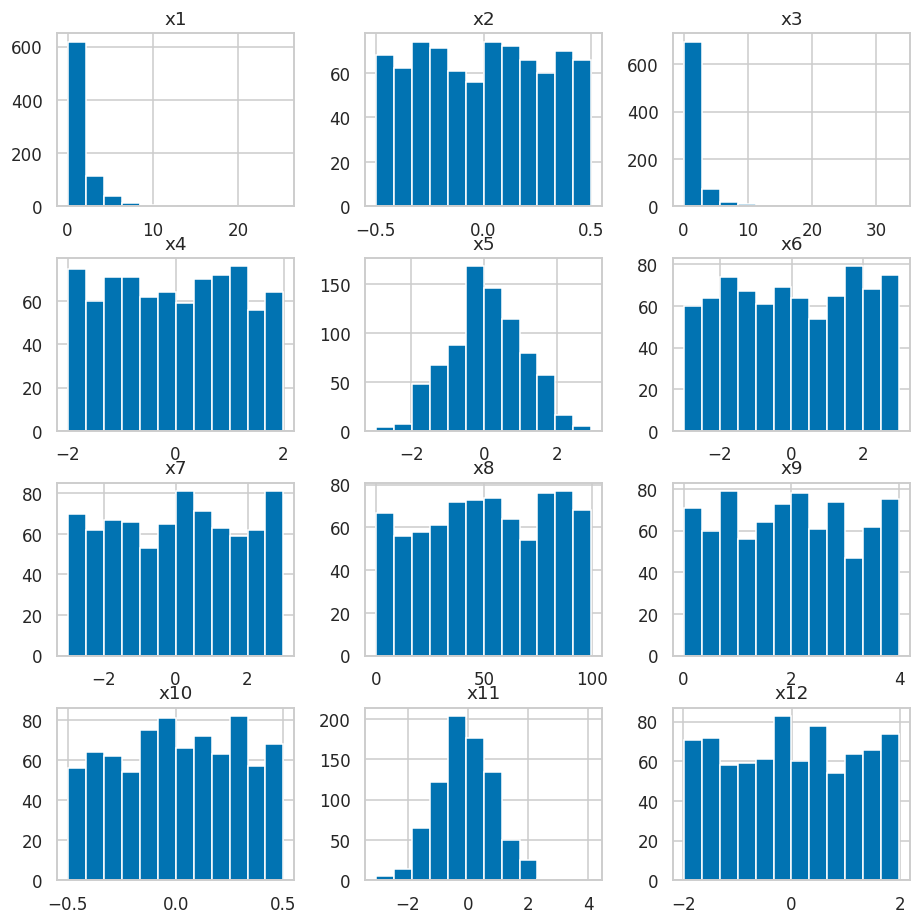

In [29]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.

train[VARIABLES].hist(bins=12, figsize=(10,10))

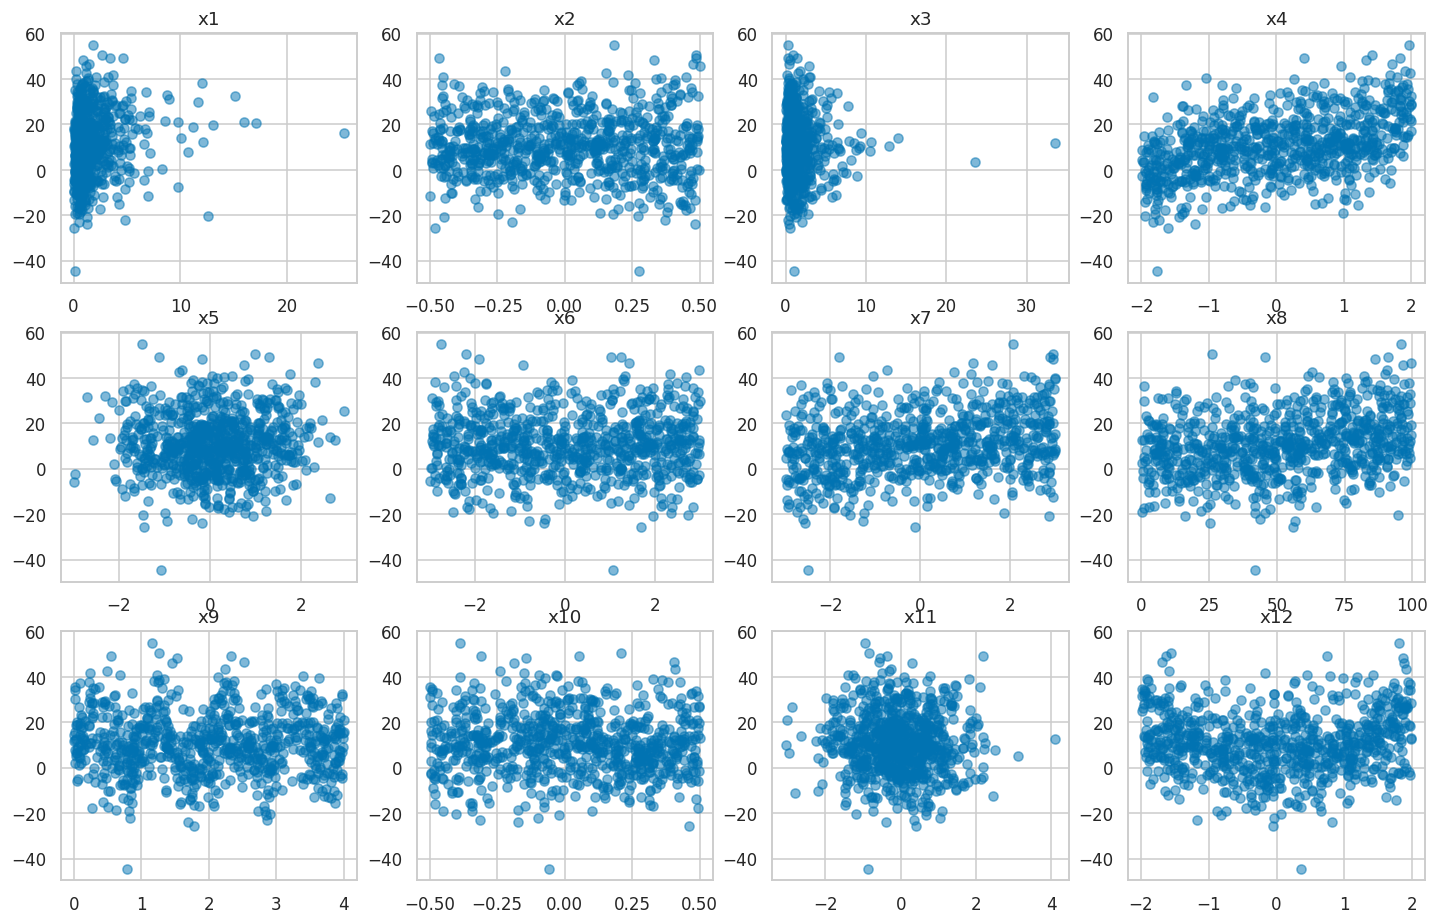

In [30]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.

plt.figure(figsize=(16, 10))
for i in range(1, 13):
    plt.subplot(3, 4, i)
    plt.scatter(train["x" + str(i)], train["y"], alpha=0.5)
    plt.title("x"+str(i))
    

In [31]:
# TODO: matriz de correlación entre las 12 variables y `y`.

train[VARIABLES + ['y']].corr()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
x1,1.000000,0.033727,-0.054571,-0.003744,0.064950,0.010345,0.035106,-0.055962,0.076630,0.010488,0.043472,0.042573,0.160104
x2,0.033727,1.000000,-0.026181,0.048158,0.030932,-0.046013,-0.046967,0.035703,-0.069217,-0.018985,-0.019218,-0.017180,-0.001895
x3,-0.054571,-0.026181,1.000000,-0.080274,-0.018230,0.045279,0.018386,0.036244,-0.002054,0.006492,-0.063115,-0.020397,-0.028458
x4,-0.003744,0.048158,-0.080274,1.000000,0.068956,0.008812,0.009608,-0.031492,0.028924,-0.062991,-0.007013,-0.011814,0.452195
x5,0.064950,0.030932,-0.018230,0.068956,1.000000,-0.006095,0.006309,-0.031425,-0.035372,-0.027548,0.010037,-0.034731,0.033048
x6,0.010345,-0.046013,0.045279,0.008812,-0.006095,1.000000,-0.012106,-0.045851,-0.051118,-0.027733,-0.021668,0.003928,0.018162
x7,0.035106,-0.046967,0.018386,0.009608,0.006309,-0.012106,1.000000,0.035880,0.019070,0.010358,-0.043985,0.004377,0.260357
x8,-0.055962,0.035703,0.036244,-0.031492,-0.031425,-0.045851,0.035880,1.000000,0.034824,0.016420,-0.035066,0.051557,0.274746
x9,0.076630,-0.069217,-0.002054,0.028924,-0.035372,-0.051118,0.019070,0.034824,1.000000,-0.012247,0.055769,0.009783,-0.021856
x10,0.010488,-0.018985,0.006492,-0.062991,-0.027548,-0.027733,0.010358,0.016420,-0.012247,1.000000,-0.015278,-0.015898,-0.051169


### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
| --- | --- | --- | --- |
| x1 | Relación no lineal (necesita transformacion) | "Dispersión x1 vs y (Fila 1, Col 1)"|Seguro|
| x2 | Sin relación lineal (ruido blanco) | "Dispersión x2 vs y (Fila 1, Col 2)" |Muy seguro|
| x3 | Acumulación masiva cerca de 0, no relacionada aunque una transformacion podria ayudar |"Dispersión x3 vs y (Fila 1, Col 3)"|Seguro|
| x4 | Relación lineal positiva clara y marcada|"Dispersión x4 vs y (Fila 1, Col 4)"|Muy seguro|
| x5 | Sin relación lineal (ruido uniforme)|"Dispersión x5 vs y (Fila 2, Col 1)"|Muy seguro|
| x6 | Sin relación lineal (ruido uniforme)|"Dispersión x6 vs y (Fila 2, Col 2)"|Muy seguro|
| x7 | Relación lineal positiva moderada|"Dispersión x7 vs y (Fila 2, Col 3)"|Seguro|
| x8 | Relación lineal positiva moderada|"Dispersión x8 vs y (Fila 2, Col 4)"|Seguro|
| x9 | Patrón periódico (forma de ola) escondido en el ruido|"Dispersión x9 vs y (Fila 3, Col 1)"|Mas o menos|
| x10 |Sin relación lineal (ruido uniforme)|"Dispersión x10 vs y (Fila 3, Col 2)"|Muy seguro|
| x11 |Sin relación lineal (ruido uniforme)|"Dispersión x11 vs y (Fila 3, Col 3)"|Muy seguro|
| x12 |Parábola centrada en 0, talvez mas relacion si se transforma|"Dispersión x12 vs y (Fila 3, Col 4)"|Mas o menos|


Muy seguro es de 90% o mas

Seguro es entre un 70%-90%

Mas o menos es entre 50%-70%

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [32]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 112.51


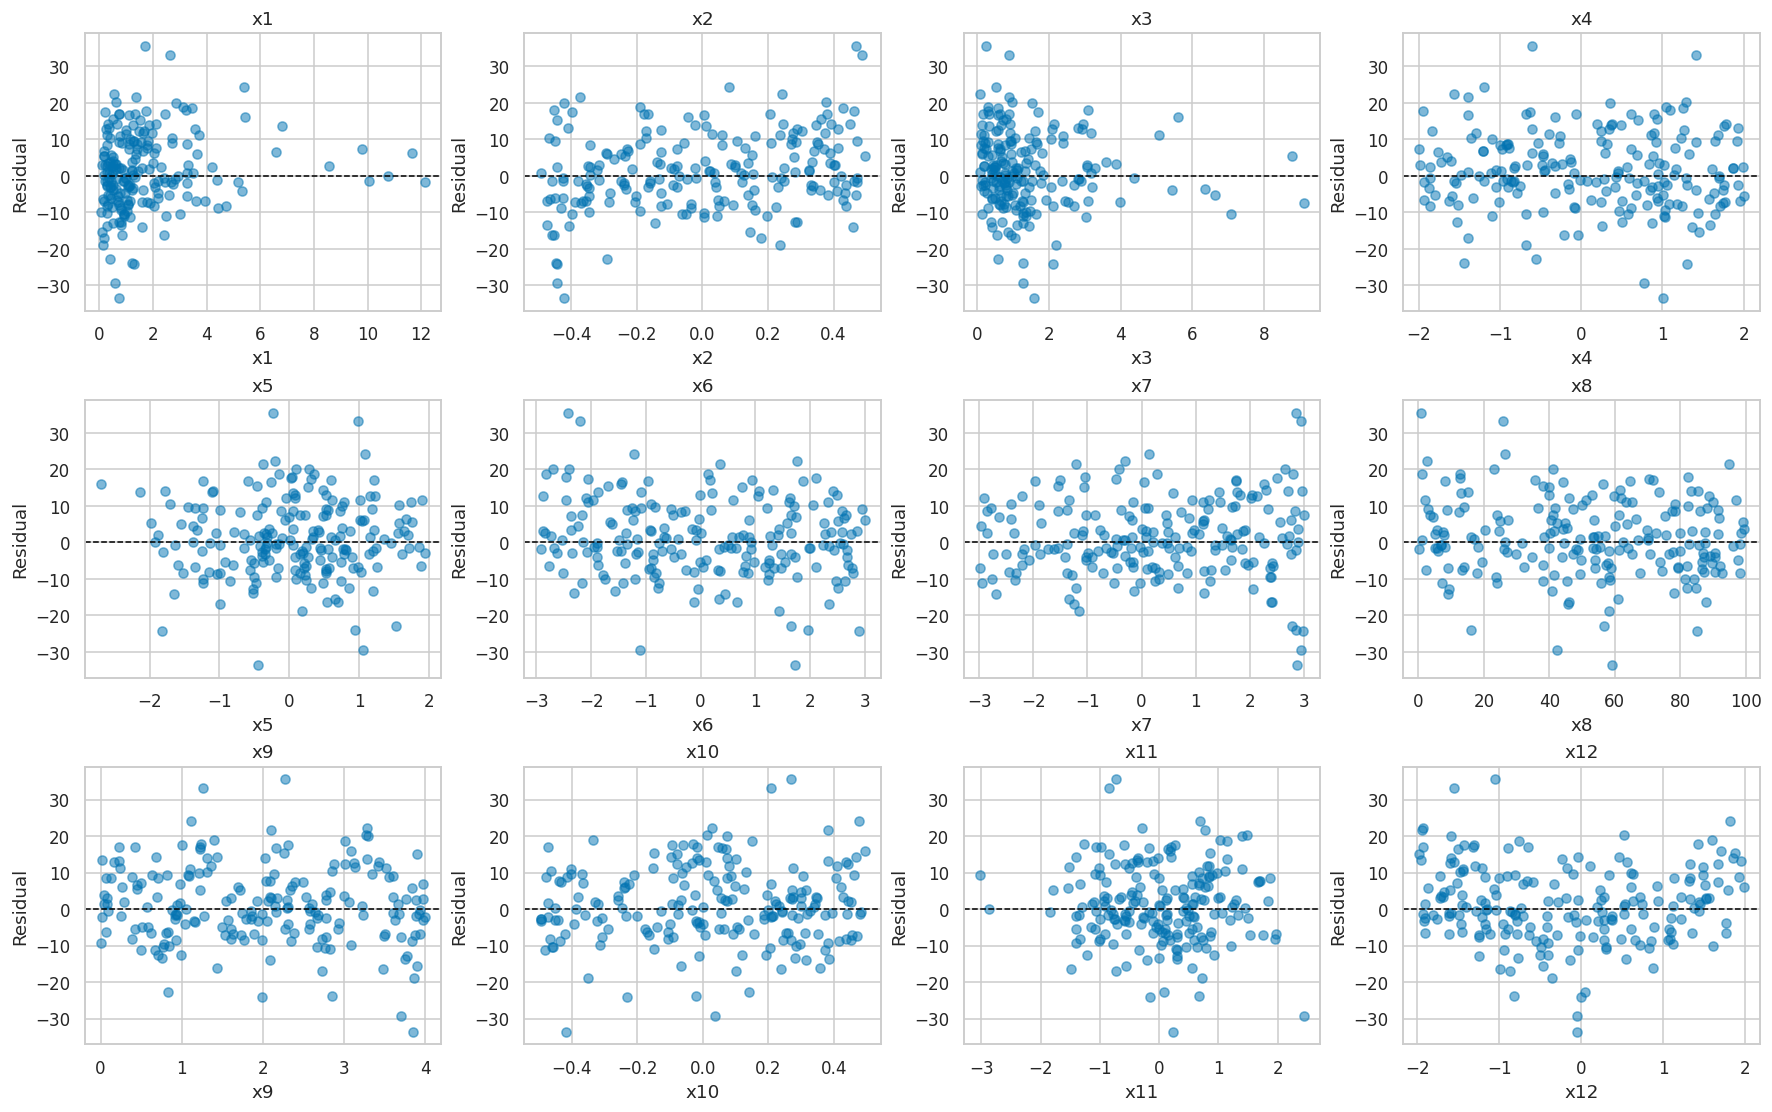

In [33]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[variable], residuales, alpha=0.5)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(variable)
    ax.set_xlabel(variable)
    ax.set_ylabel("Residual")

plt.show()

In [85]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

# 1. Pruebas de transformaciones por separado 
modelo, mse, residuales, _ = ajusta({"x1_log": lambda d: np.log(d["x1"])})
print(f"MSE solo con x1 logarítmica: {mse:.2f}")

modelo, mse, residuales, _ = ajusta({"x12_cuadrada": lambda d: d["x12"] ** 2})
print(f"MSE solo con x12 al cuadrado: {mse:.2f}")

modelo, mse, residuales, _ = ajusta({"x3_log": lambda d: np.log(d["x3"])})
print(f"MSE con x3 logarítmica: {mse:.2f}")

modelo, mse, residuales, _ = ajusta({"x9_seno": lambda d: np.sin(d["x9"])})
print(f"MSE solo con x9 senoidal: {mse:.2f}")

modelo, mse, residuales, _ = ajusta({"x9_coseno": lambda d: np.cos(d["x9"])})
print(f"MSE solo con x9 cosenoidal: {mse:.2f}")

#X1 y X3 me estaban dando muchos problemas asi que hice muchas pruebas
print("\n--- Pruebas individuales para x1 ---")
modelo, mse, _, _ = ajusta({"x1_log": lambda d: np.log(d["x1"] + 1e-5)}) # +1e-5 evita errores con ceros
print(f"MSE logaritmo: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x1_sqrt": lambda d: np.sqrt(d["x1"])})
print(f"MSE raíz cuadrada: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x1_cuadrada": lambda d: d["x1"] ** 2})
print(f"MSE cuadrado: {mse:.2f}")


print("\n--- Pruebas individuales para x3 ---")
modelo, mse, _, _ = ajusta({"x3_log_seguro": lambda d: np.log(d["x3"] + 1)}) # log(x+1) es seguro para ceros
print(f"MSE logaritmo seguro: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x3_sqrt": lambda d: np.sqrt(d["x3"])})
print(f"MSE raíz cuadrada: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x3_cuadrada": lambda d: d["x3"] ** 2})
print(f"MSE cuadrado: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x3_inversa": lambda d: 1 / (d["x3"] + 1)})
print(f"MSE inversa: {mse:.2f}")

print("\n--- Prueba para x1 y x3 juntas ---")
modelo, mse, _, _ = ajusta({"x3+x1": lambda d: d["x3"] + d["x1"]}) # 
print(f"MSE x3+x1: {mse:.2f}")
modelo, mse, residuales, _ = ajusta({"x1_por_x3": lambda d: d["x1"] * d["x3"]})
print(f"MSE solo con interacción x1 * x3: {mse:.2f}")

# 2. Todas las transformaciones exitosas evaluadas de forma conjunta
transformaciones_combinadas = {
    "x1_log": lambda d: np.sqrt(d["x1"]),
    "x3_log": lambda d: np.log(d["x3"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2
}
modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_combinadas)
print(f"\nMSE con ajustes combinados_1: {mse_final:.2f}")

transformaciones_combinadas = {
    "x1_log": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2
}

modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_combinadas)
print(f"MSE con ajustes combinados_2: {mse_final:.2f}")

transformaciones_combinadas = {
    "x1_log": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2
}
modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_combinadas)
print(f"MSE con ajustes combinados_3: {mse_final:.2f}")

transformaciones_combinadas = {
    "x1_log": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1+x3": lambda d: d["x1"] + d["x3"]
}
modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_combinadas)
print(f"MSE con ajustes combinados_4: {mse_final:.2f}")

transformaciones_combinadas = {
    "x1_log": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1*x3": lambda d: d["x1"] * d["x3"]
}
modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_combinadas)
print(f"MSE con ajustes combinados_5: {mse_final:.2f}")


MSE solo con x1 logarítmica: 108.80
MSE solo con x12 al cuadrado: 96.38
MSE con x3 logarítmica: 112.72
MSE solo con x9 senoidal: 113.84
MSE solo con x9 cosenoidal: 111.54

--- Pruebas individuales para x1 ---
MSE logaritmo: 108.80
MSE raíz cuadrada: 108.07
MSE cuadrado: 108.62

--- Pruebas individuales para x3 ---
MSE logaritmo seguro: 112.13
MSE raíz cuadrada: 112.26
MSE cuadrado: 112.40
MSE inversa: 112.24

--- Prueba para x1 y x3 juntas ---
MSE x3+x1: 112.51
MSE solo con interacción x1 * x3: 112.47

MSE con ajustes combinados_1: 90.89
MSE con ajustes combinados_2: 92.36
MSE con ajustes combinados_3: 89.59
MSE con ajustes combinados_4: 89.59
MSE con ajustes combinados_5: 90.11


In [54]:
# 1. Tu mejor base acumulada hasta el momento (MSE ~90.06)
base_actual = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
}

variables = [f"x{i}" for i in range(1, 13)]

print("--- Interacciones para x1 (sobre base limpia) ---")
for var in variables:
    if var != "x1":
        prueba = base_actual.copy()
        prueba[f"x1_por_{var}"] = lambda d, col=var: d["x1"] * d[col]
        _, mse, _, _ = ajusta(prueba)
        print(f"MSE base + (x1 * {var}): {mse:.2f}")

print("\n--- Interacciones para x3 (sobre base limpia) ---")
for var in variables:
    if var != "x3":
        prueba = base_actual.copy()
        prueba[f"x3_por_{var}"] = lambda d, col=var: d["x3"] * d[col]
        _, mse, _, _ = ajusta(prueba)
        print(f"MSE base + (x3 * {var}): {mse:.2f}")


--- Interacciones para x1 (sobre base limpia) ---
MSE base + (x1 * x2): 89.53
MSE base + (x1 * x3): 90.11
MSE base + (x1 * x4): 89.81
MSE base + (x1 * x5): 89.77
MSE base + (x1 * x6): 89.89
MSE base + (x1 * x7): 88.77
MSE base + (x1 * x8): 89.70
MSE base + (x1 * x9): 89.67
MSE base + (x1 * x10): 90.26
MSE base + (x1 * x11): 89.76
MSE base + (x1 * x12): 89.51

--- Interacciones para x3 (sobre base limpia) ---
MSE base + (x3 * x1): 90.11
MSE base + (x3 * x2): 91.75
MSE base + (x3 * x4): 89.56
MSE base + (x3 * x5): 89.63
MSE base + (x3 * x6): 89.71
MSE base + (x3 * x7): 89.23
MSE base + (x3 * x8): 89.57
MSE base + (x3 * x9): 89.61
MSE base + (x3 * x10): 89.66
MSE base + (x3 * x11): 89.70
MSE base + (x3 * x12): 90.49


In [55]:
# 1. Tu mejor base acumulada hasta el momento (MSE ~90.06)
base_actual = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
}

variables = [f"x{i}" for i in range(1, 13)]

print("--- Interacciones para x1 (sobre base limpia) ---")
for var in variables:
    if var != "x1":
        prueba = base_actual.copy()
        prueba[f"x1_por_{var}"] = lambda d, col=var: d["x1"] / d[col]
        _, mse, _, _ = ajusta(prueba)
        print(f"MSE base + (x1 / {var}): {mse:.2f}")

print("\n--- Interacciones para x3 (sobre base limpia) ---")
for var in variables:
    if var != "x3":
        prueba = base_actual.copy()
        prueba[f"x3_por_{var}"] = lambda d, col=var: d["x3"] / d[col]
        _, mse, _, _ = ajusta(prueba)
        print(f"MSE base + (x3 / {var}): {mse:.2f}")


--- Interacciones para x1 (sobre base limpia) ---
MSE base + (x1 / x2): 89.57
MSE base + (x1 / x3): 89.98
MSE base + (x1 / x4): 91.65
MSE base + (x1 / x5): 89.65
MSE base + (x1 / x6): 99.13
MSE base + (x1 / x7): 89.59
MSE base + (x1 / x8): 93.44
MSE base + (x1 / x9): 89.95
MSE base + (x1 / x10): 89.57
MSE base + (x1 / x11): 89.53
MSE base + (x1 / x12): 89.16

--- Interacciones para x3 (sobre base limpia) ---
MSE base + (x3 / x1): 89.37
MSE base + (x3 / x2): 89.17
MSE base + (x3 / x4): 89.62
MSE base + (x3 / x5): 89.59
MSE base + (x3 / x6): 89.59
MSE base + (x3 / x7): 112.54
MSE base + (x3 / x8): 89.81
MSE base + (x3 / x9): 89.61
MSE base + (x3 / x10): 89.67
MSE base + (x3 / x11): 90.09
MSE base + (x3 / x12): 89.82


In [56]:
# 1. Base con el ganador de x1 (MSE: 88.77)
base_x1 = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
}

# 2. Tu hipótesis: juntar el mejor de x1 (x1*x7) con el mejor de x3 (x3*x7)
hipotesis_juntas = base_x1.copy()
hipotesis_juntas["x3_por_x7"] = lambda d: d["x3"] * d["x7"]

_, mse_juntos, _, _ = ajusta(hipotesis_juntas)
print(f"MSE juntando (x1*x7) + (x3*x7): {mse_juntos:.2f}")

MSE juntando (x1*x7) + (x3*x7): 88.47


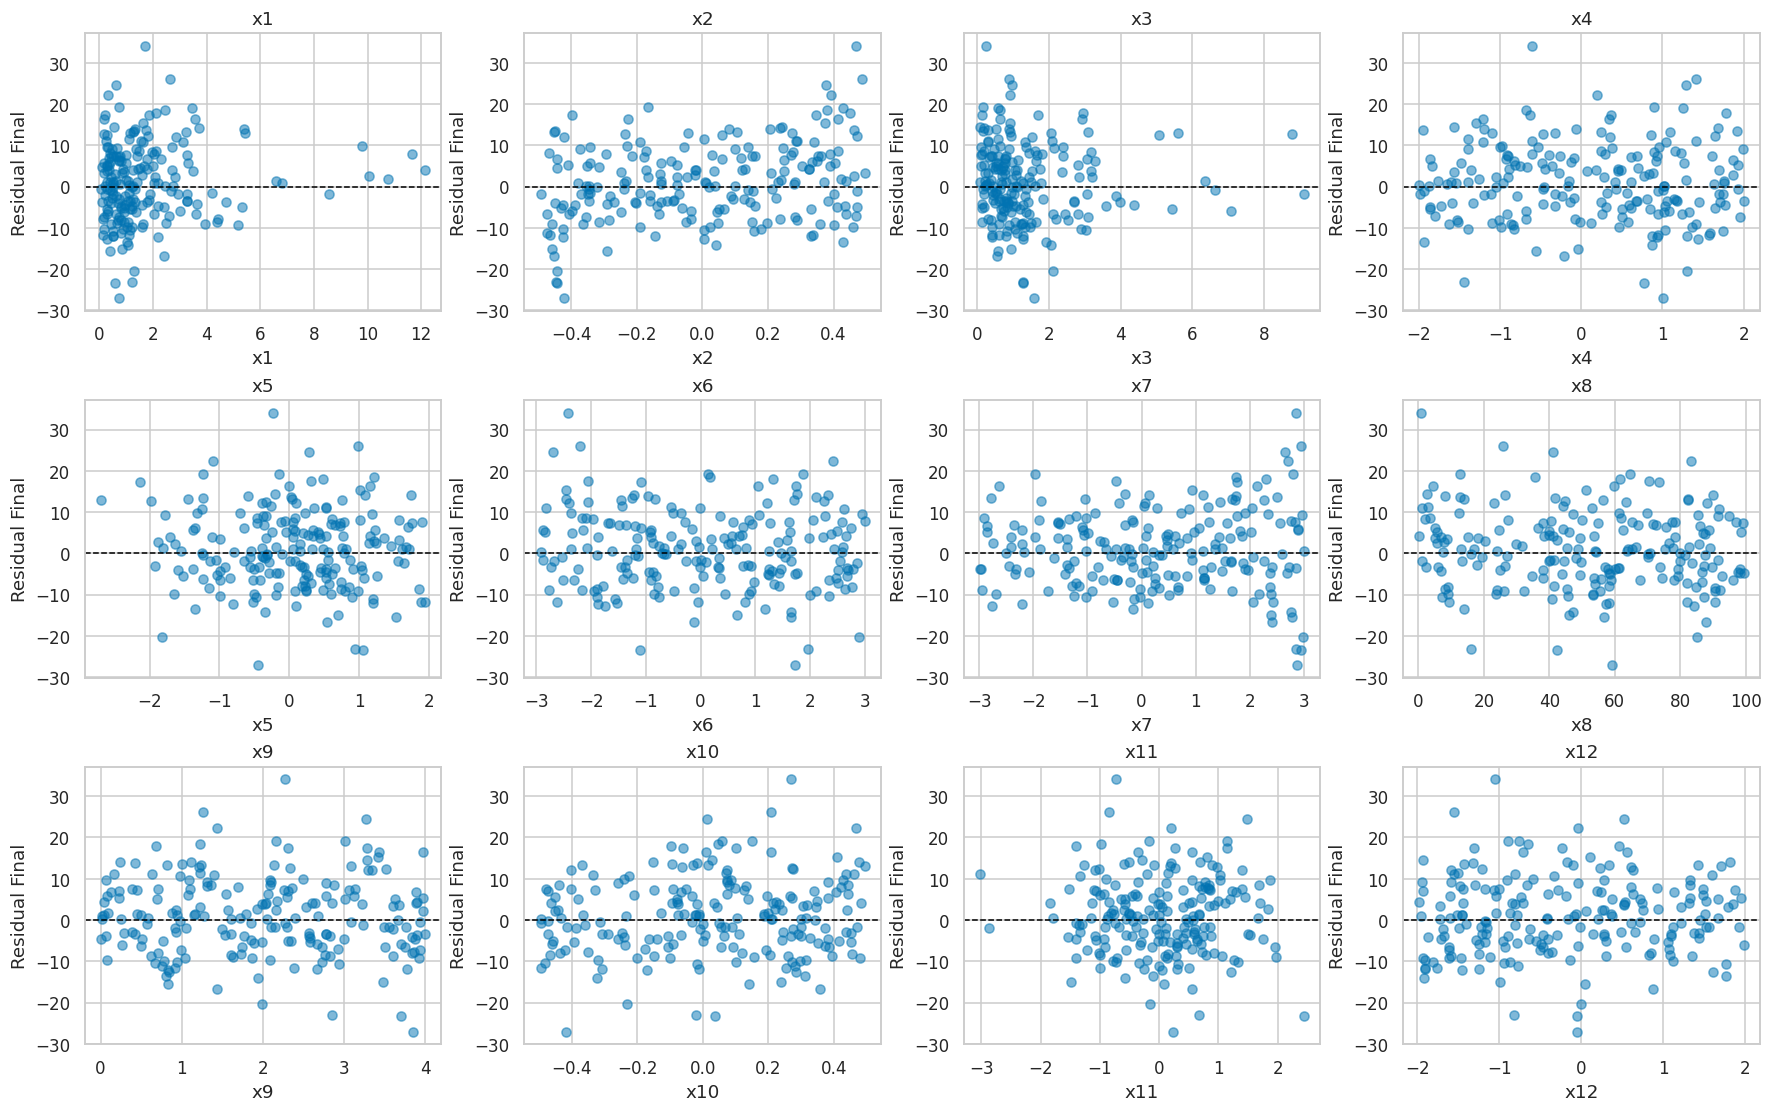

In [57]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[variable], residuales_final, alpha=0.5)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(variable)
    ax.set_xlabel(variable)
    ax.set_ylabel("Residual Final")

plt.show()

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [58]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.

import itertools

# 1. Base sólida actualizada tras las pruebas individuales y combinadas (MSE ~88.47)
transformaciones_base = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
}

print("--- Escaneando términos adicionales sobre la base de 88.47 ---")

# A. Evaluamos todos los pares de interacciones restantes (excluyendo los que ya están en la base)
resultados_interacciones = []
for var1, var2 in itertools.combinations(VARIABLES, 2):
    if (var1, var2) in [("x1", "x7"), ("x7", "x1"), ("x3", "x7"), ("x7", "x3")]:
        continue

    dicc = transformaciones_base.copy()
    dicc[f"{var1}_por_{var2}"] = lambda d, c1=var1, c2=var2: d[c1] * d[c2]

    _, mse, _, _ = ajusta(dicc)
    resultados_interacciones.append((mse, f"{var1} * {var2}"))

# B. Evaluamos términos cuadráticos adicionales que no tengamos en la base
resultados_cuadraticos = []
for var in VARIABLES:
    if var == "x12":  # x12_cuadrada ya está incluida
        continue

    dicc = transformaciones_base.copy()
    dicc[f"{var}_cuadrada"] = lambda d, v=var: d[v] ** 2

    _, mse, _, _ = ajusta(dicc)
    resultados_cuadraticos.append((mse, f"{var}**2"))

# Combinamos y ordenamos para ver cuáles bajan más el error
todos_los_candidatos = resultados_interacciones + resultados_cuadraticos
todos_los_candidatos.sort()

print("\nLos 5 términos que más bajan el MSE de 88.47:")
for mse, desc in todos_los_candidatos[:5]:
    print(f"MSE: {mse:.2f} -> {desc}")

--- Escaneando términos adicionales sobre la base de 88.47 ---

Los 5 términos que más bajan el MSE de 88.47:
MSE: 50.56 -> x2 * x7
MSE: 86.96 -> x6 * x7
MSE: 87.61 -> x2 * x4
MSE: 87.70 -> x6 * x9
MSE: 87.76 -> x8**2


In [59]:

base_actualizada = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],  
}

print("--- Escaneando sobre el nuevo piso de MSE: 50.56 ---")

candidatos_siguiente = []

# A. Interacciones de pares restantes
for v1, v2 in itertools.combinations(VARIABLES, 2):
    if (v1, v2) in [("x1","x7"), ("x7","x1"), ("x3","x7"), ("x7","x3"), ("x2","x7"), ("x7","x2")]:
        continue
    dicc = base_actualizada.copy()
    dicc[f"{v1}_por_{v2}"] = lambda d, c1=v1, c2=v2: d[c1] * d[c2]
    _, mse, _, _ = ajusta(dicc)
    candidatos_siguiente.append((mse, f"{v1} * {v2}"))

# B. Cuadrados restantes
for v in VARIABLES:
    if v == "x12":
        continue
    dicc = base_actualizada.copy()
    dicc[f"{v}_cuadrada"] = lambda d, var=v: d[var] ** 2
    _, mse, _, _ = ajusta(dicc)
    candidatos_siguiente.append((mse, f"{v}**2"))

# C. Seno de x9 para completar la onda con coseno
dicc = base_actualizada.copy()
dicc["x9_seno"] = lambda d: np.sin(d["x9"])
_, mse, _, _ = ajusta(dicc)
candidatos_siguiente.append((mse, "x9_seno"))

candidatos_siguiente.sort()

print("\nTop 5 términos que más bajan el MSE de 50.56:")
for mse, desc in candidatos_siguiente[:5]:
    print(f"MSE: {mse:.2f} -> {desc}")

--- Escaneando sobre el nuevo piso de MSE: 50.56 ---

Top 5 términos que más bajan el MSE de 50.56:
MSE: 49.92 -> x6 * x9
MSE: 50.08 -> x6 * x7
MSE: 50.12 -> x8**2
MSE: 50.24 -> x7 * x12
MSE: 50.25 -> x1 * x6


In [61]:
# Base de 8 términos incluyendo x6 * x9 (MSE: 49.92)
base_actualizada = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],
    "x6_por_x9": lambda d: d["x6"] * d["x9"],
}

print("--- Escaneo Avanzado (Protegido contra valores negativos) ---")

candidatos_avanzados = {}

# Identificamos variables estrictamente no negativas para raíz segura
vars_positivas = [v for v in VARIABLES if (train[v] >= 0).all()]

# A. Trigonometría de doble frecuencia y Seno complementario
for v in VARIABLES:
    candidatos_avanzados[f"{v}_seno"] = lambda d, var=v: np.sin(d[var])
    candidatos_avanzados[f"{v}_seno2"] = lambda d, var=v: np.sin(2 * d[var])
    candidatos_avanzados[f"{v}_coseno2"] = lambda d, var=v: np.cos(2 * d[var])

# B. Interacciones de x7 con trigonometría y raíces seguras
for v in VARIABLES:
    if v != "x7":
        candidatos_avanzados[f"x7_por_sin_{v}"] = lambda d, var=v: d["x7"] * np.sin(d[var])
        candidatos_avanzados[f"x7_por_cos_{v}"] = lambda d, var=v: d["x7"] * np.cos(d[var])
        if v in vars_positivas:
            candidatos_avanzados[f"x7_por_sqrt_{v}"] = lambda d, var=v: d["x7"] * np.sqrt(d[var])

# C. Interacciones con las transformadas de la base
for v in VARIABLES:
    candidatos_avanzados[f"sqrt_x1_por_{v}"] = lambda d, var=v: np.sqrt(d["x1"]) * d[var]
    candidatos_avanzados[f"cos_x9_por_{v}"] = lambda d, var=v: np.cos(d["x9"]) * d[var]
    candidatos_avanzados[f"x12_2_por_{v}"] = lambda d, var=v: (d["x12"] ** 2) * d[var]

# Evaluamos cada candidato
resultados_avanzados = []
for nombre, fn in candidatos_avanzados.items():
    if nombre in base_actualizada:
        continue
    dicc = base_actualizada.copy()
    dicc[nombre] = fn
    _, mse, _, _ = ajusta(dicc)
    if np.isfinite(mse):
        resultados_avanzados.append((mse, nombre))

resultados_avanzados.sort()

print("\nTop 10 candidatos avanzados que más reducen el MSE de 49.92:")
for mse, nombre in resultados_avanzados[:10]:
    print(f"MSE: {mse:.2f} -> {nombre}")

--- Escaneo Avanzado (Protegido contra valores negativos) ---

Top 10 candidatos avanzados que más reducen el MSE de 49.92:
MSE: 47.59 -> x4_seno
MSE: 48.08 -> x4_seno2
MSE: 48.73 -> x7_coseno2
MSE: 49.18 -> cos_x9_por_x6
MSE: 49.42 -> x11_coseno2
MSE: 49.45 -> x3_seno
MSE: 49.47 -> x7_por_sin_x6
MSE: 49.57 -> x7_por_sin_x3
MSE: 49.65 -> x7_por_cos_x8
MSE: 49.66 -> sqrt_x1_por_x6


In [62]:
# Base actualizada con 9 términos (MSE ~47.59)
base_actualizada = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],
    "x6_por_x9": lambda d: d["x6"] * d["x9"],
    "x4_seno": lambda d: np.sin(d["x4"]),  # ¡El nuevo ganador! MSE: 47.59
}

print("--- Escaneo sobre el nuevo piso de MSE: 47.59 ---")

candidatos_siguiente = {}

# A. Complementos para x4 (coseno, frecuencias dobles)
candidatos_siguiente["x4_coseno"] = lambda d: np.cos(d["x4"])
candidatos_siguiente["x4_seno2"] = lambda d: np.sin(2 * d["x4"])
candidatos_siguiente["x4_coseno2"] = lambda d: np.cos(2 * d["x4"])

# B. Interacciones de la moduladora x7 con trigonometría
for v in VARIABLES:
    if v != "x7":
        candidatos_siguiente[f"x7_por_sin_{v}"] = lambda d, var=v: d["x7"] * np.sin(d[var])
        candidatos_siguiente[f"x7_por_cos_{v}"] = lambda d, var=v: d["x7"] * np.cos(d[var])

# C. Frecuencias dobles del resto de las variables
for v in VARIABLES:
    candidatos_siguiente[f"{v}_coseno2"] = lambda d, var=v: np.cos(2 * d[var])
    candidatos_siguiente[f"{v}_seno2"] = lambda d, var=v: np.sin(2 * d[var])

# D. Interacción de x4_seno con el modulador x7
candidatos_siguiente["x7_por_x4_seno"] = lambda d: d["x7"] * np.sin(d["x4"])

# Evaluamos candidatos
resultados_siguiente = []
for nombre, fn in candidatos_siguiente.items():
    if nombre in base_actualizada:
        continue
    dicc = base_actualizada.copy()
    dicc[nombre] = fn
    _, mse, _, _ = ajusta(dicc)
    if np.isfinite(mse):
        resultados_siguiente.append((mse, nombre))

resultados_siguiente.sort()

print("\nTop 10 candidatos que más reducen el MSE de 47.59:")
for mse, nombre in resultados_siguiente[:10]:
    print(f"MSE: {mse:.2f} -> {nombre}")

--- Escaneo sobre el nuevo piso de MSE: 47.59 ---

Top 10 candidatos que más reducen el MSE de 47.59:
MSE: 46.24 -> x7_coseno2
MSE: 47.04 -> x11_coseno2
MSE: 47.16 -> x7_por_sin_x6
MSE: 47.17 -> x7_por_sin_x3
MSE: 47.29 -> x10_seno2
MSE: 47.29 -> x7_por_cos_x10
MSE: 47.30 -> x7_por_cos_x5
MSE: 47.31 -> x7_por_sin_x12
MSE: 47.35 -> x7_por_sin_x5
MSE: 47.35 -> x9_coseno2


In [65]:


# 1. Tu base actual de 12 términos (Piso: 44.23)
base_actual = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x3_log": lambda d: np.log(d["x3"] + 1e-5),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],
    "x6_por_x9": lambda d: d["x6"] * d["x9"],
    "x4_seno": lambda d: np.sin(d["x4"]),
    "x7_coseno2": lambda d: np.cos(2 * d["x7"]),
    "x8_cbrt": lambda d: np.cbrt(d["x8"]),
    "sin_x3_por_cos_x11": lambda d: np.sin(d["x3"]) * np.cos(d["x11"]),
}

# 2. Generador de catálogo completo de candidatas no lineales
def generar_candidatos_totales(base_keys):
    candidatos = {}

    # Univariadas (Especiales, Trigonométricas, Cuadráticas)
    for v in VARIABLES:
        candidatos[f"{v}_seno"] = lambda d, var=v: np.sin(d[var])
        candidatos[f"{v}_coseno"] = lambda d, var=v: np.cos(d[var])
        candidatos[f"{v}_seno2"] = lambda d, var=v: np.sin(2 * d[var])
        candidatos[f"{v}_coseno2"] = lambda d, var=v: np.cos(2 * d[var])
        candidatos[f"{v}_log"] = lambda d, var=v: np.log(np.abs(d[var]) + 1e-5)
        candidatos[f"{v}_inversa"] = lambda d, var=v: 1.0 / (np.abs(d[var]) + 1e-5)
        candidatos[f"{v}_cbrt"] = lambda d, var=v: np.cbrt(d[var])
        candidatos[f"{v}_cuadrada"] = lambda d, var=v: d[var] ** 2

    # Interacciones compuestas cruzadas entre todos los pares (v1 != v2)
    for v1, v2 in itertools.combinations(VARIABLES, 2):
        candidatos[f"{v1}_por_{v2}"] = lambda d, a=v1, b=v2: d[a] * d[b]
        candidatos[f"sin_{v1}_por_{v2}"] = lambda d, a=v1, b=v2: np.sin(d[a]) * d[b]
        candidatos[f"cos_{v1}_por_{v2}"] = lambda d, a=v1, b=v2: np.cos(d[a]) * d[b]
        candidatos[f"log_{v1}_por_{v2}"] = lambda d, a=v1, b=v2: np.log(np.abs(d[a]) + 1e-5) * d[b]
        candidatos[f"inv_{v1}_por_{v2}"] = lambda d, a=v1, b=v2: (1.0 / (np.abs(d[a]) + 1e-5)) * d[b]
        candidatos[f"sin_{v1}_por_cos_{v2}"] = lambda d, a=v1, b=v2: np.sin(d[a]) * np.cos(d[b])
        candidatos[f"sin_{v1}_por_sin_{v2}"] = lambda d, a=v1, b=v2: np.sin(d[a]) * np.sin(d[b])
        candidatos[f"cos_{v1}_por_cos_{v2}"] = lambda d, a=v1, b=v2: np.cos(d[a]) * np.cos(d[b])

    # Excluimos las que ya forman parte de la base actual
    return {k: v for k, v in candidatos.items() if k not in base_keys}

# 3. Parámetros de parada
TARGET_MSE = 23.47
UMBRAL_MEJORA_MINIMA = 0.05  # Detiene si la mejora es menor a 0.05 unidades
MAX_ITERACIONES = 30

_, mse_actual, _, _ = ajusta(base_actual)
print(f"--- Inicio de Selección Automática ---")
print(f"MSE Inicial: {mse_actual:.2f}\n" + "-" * 50)

# 4. Bucle principal de optimización
paso = 1
while mse_actual > TARGET_MSE and paso <= MAX_ITERACIONES:
    candidatos = generar_candidatos_totales(base_actual.keys())
    
    mejor_nombre = None
    mejor_mse = mse_actual
    mejor_fn = None

    # Evaluamos todos los candidatos del catálogo
    for nombre, fn in candidatos.items():
        prueba = base_actual.copy()
        prueba[nombre] = fn
        _, mse, _, _ = ajusta(prueba)

        if np.isfinite(mse) and mse < mejor_mse:
            mejor_mse = mse
            mejor_nombre = nombre
            mejor_fn = fn

    mejora = mse_actual - mejor_mse

    # Si encontramos un término que reduzca el MSE por encima del umbral, lo agregamos
    if mejor_nombre is not None and mejora >= UMBRAL_MEJORA_MINIMA:
        base_actual[mejor_nombre] = mejor_fn
        mse_actual = mejor_mse
        print(f"Paso {paso:02d}: + '{mejor_nombre}' | Nuevo MSE: {mse_actual:.2f} (Mejora: -{mejora:.2f})")
        paso += 1
    else:
        print("\nSe alcanzó un estancamiento (mejora inferior al umbral mínimo).")
        break

print("-" * 50)
print(f"Proceso finalizado. MSE alcanzado: {mse_actual:.2f} con {len(base_actual)} términos.")

--- Inicio de Selección Automática ---
MSE Inicial: 44.23
--------------------------------------------------
Paso 01: + 'log_x4_por_x5' | Nuevo MSE: 43.58 (Mejora: -0.65)
Paso 02: + 'cos_x10_por_x11' | Nuevo MSE: 42.91 (Mejora: -0.67)
Paso 03: + 'sin_x8_por_x10' | Nuevo MSE: 42.29 (Mejora: -0.63)
Paso 04: + 'log_x5_por_x7' | Nuevo MSE: 41.70 (Mejora: -0.58)
Paso 05: + 'inv_x11_por_x12' | Nuevo MSE: 41.15 (Mejora: -0.55)
Paso 06: + 'x5_por_x7' | Nuevo MSE: 40.69 (Mejora: -0.47)
Paso 07: + 'cos_x1_por_cos_x5' | Nuevo MSE: 40.24 (Mejora: -0.45)
Paso 08: + 'sin_x10_por_cos_x11' | Nuevo MSE: 39.73 (Mejora: -0.51)
Paso 09: + 'sin_x2_por_sin_x11' | Nuevo MSE: 39.31 (Mejora: -0.43)
Paso 10: + 'x2_log' | Nuevo MSE: 38.90 (Mejora: -0.41)
Paso 11: + 'cos_x5_por_cos_x6' | Nuevo MSE: 38.49 (Mejora: -0.41)
Paso 12: + 'inv_x3_por_x4' | Nuevo MSE: 38.13 (Mejora: -0.35)
Paso 13: + 'sin_x5_por_x11' | Nuevo MSE: 37.81 (Mejora: -0.33)
Paso 14: + 'sin_x3_por_x11' | Nuevo MSE: 37.48 (Mejora: -0.32)
Paso 15:

In [67]:
import itertools
import numpy as np
import pandas as pd
from scipy import stats

# ==============================================================================
# FASE 1: LIMPIEZA Y PURGA (PRUNING POR P-VALUE SIN STATSMODELS)
# ==============================================================================
print("=== FASE 1: PURGANDO RUIDO POR P-VALUE (< 0.05) ===")

# 1. Construir la matriz de diseño X con intersección (constante)
X_df = pd.DataFrame(index=train.index)
for nombre, fn in base_actual.items():
    X_df[nombre] = fn(train)

X = X_df.values
y = train["y"].values
n, p = X.shape

# Agregar columna de unos para el intercepto
X_design = np.hstack([np.ones((n, 1)), X])
n, p_full = X_design.shape

# 2. Cálculo OLS y p-values mediante álgebra matricial
beta, residuals, rank, s = np.linalg.lstsq(X_design, y, rcond=None)
y_pred = X_design @ beta
e = y - y_pred
df_residual = n - p_full
sigma2 = np.sum(e**2) / df_residual

# Matriz de covarianza de coeficientes
cov_beta = sigma2 * np.linalg.inv(X_design.T @ X_design)
se = np.sqrt(np.diag(cov_beta))

# Estadístico t y p-values (distribución t de Student)
t_stats = beta / se
p_values_array = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df_residual))

# Mapear p-values a los nombres de las variables
nombres_columnas = ["constante"] + list(X_df.columns)
p_values = pd.Series(p_values_array, index=nombres_columnas)

print("P-values de las variables actuales:")
print(p_values.round(4))

# 3. Filtrar términos estadísticamente significativos (p-value < 0.05)
terminos_significativos = [
    col for col in X_df.columns if p_values[col] < 0.05
]

# Reconstruir la base purificada
base_purificada = {k: base_actual[k] for k in terminos_significativos}

_, mse_purificado, _, _ = ajusta(base_purificada)
print("-" * 60)
print(f"Términos retenidos tras la purga: {len(base_purificada)} de {len(base_actual)}")
print(f"Nuevo MSE base (sin ruido): {mse_purificado:.2f}")
print("-" * 60)


# ==============================================================================
# FASE 2: BÚSQUEDA DE ORDEN SUPERIOR (TRIPLES Y COCIENTES)
# ==============================================================================
print("\n=== FASE 2: ESCANEO DE TRIPLES INTERACCIONES Y COCIENTES PROTEGIDOS ===")

candidatos_orden_superior = {}

# A. Productos Triples con el Modulador Principal x7 (x_i * x_j * x7)
vars_sin_x7 = [v for v in VARIABLES if v != "x7"]
for v1, v2 in itertools.combinations(vars_sin_x7, 2):
    candidatos_orden_superior[f"{v1}_por_{v2}_por_x7"] = lambda d, a=v1, b=v2: d[a] * d[b] * d["x7"]
    candidatos_orden_superior[f"sin_{v1}_por_{v2}_por_x7"] = lambda d, a=v1, b=v2: np.sin(d[a]) * d[b] * d["x7"]
    candidatos_orden_superior[f"cos_{v1}_por_{v2}_por_x7"] = lambda d, a=v1, b=v2: np.cos(d[a]) * d[b] * d["x7"]

# B. Cocientes Directos Protegidos (x_i / (|x_j| + eps))
for v1, v2 in itertools.permutations(VARIABLES, 2):
    candidatos_orden_superior[f"div_{v1}_entre_{v2}"] = lambda d, a=v1, b=v2: d[a] / (np.abs(d[b]) + 1e-5)

# C. Cocientes Modulados con x7: (x_i * x7) / (|x_j| + eps)
for v1, v2 in itertools.permutations(vars_sin_x7, 2):
    candidatos_orden_superior[f"div_x7_por_{v1}_entre_{v2}"] = lambda d, a=v1, b=v2: (d["x7"] * d[a]) / (np.abs(d[b]) + 1e-5)

# Evaluamos todos los candidatos sobre la base purificada
resultados_orden_superior = []
for nombre, fn in candidatos_orden_superior.items():
    if nombre in base_purificada:
        continue
    prueba = base_purificada.copy()
    prueba[nombre] = fn
    _, mse, _, _ = ajusta(prueba)
    if np.isfinite(mse):
        resultados_orden_superior.append((mse, nombre, fn))

resultados_orden_superior.sort()

print(f"\nSe evaluaron {len(resultados_orden_superior)} candidatos de orden superior.")
print("Top 10 términos que logran los saltos más grandes en el MSE:")
print("-" * 60)
for mse, nombre, _ in resultados_orden_superior[:10]:
    mejora = mse_purificado - mse
    print(f"MSE: {mse:.2f} (Caída: -{mejora:.2f}) -> {nombre}")

=== FASE 1: PURGANDO RUIDO POR P-VALUE (< 0.05) ===
P-values de las variables actuales:
constante              0.3405
x1_sqrt                0.0000
x9_coseno              0.0090
x3_log                 0.2109
x12_cuadrada           0.0000
x1_por_x7              0.0000
x3_por_x7              0.0070
x2_por_x7              0.0000
x6_por_x9              0.6000
x4_seno                0.0000
x7_coseno2             0.0073
x8_cbrt                0.2565
sin_x3_por_cos_x11     0.0010
log_x4_por_x5          0.0239
cos_x10_por_x11        0.2842
sin_x8_por_x10         0.0056
log_x5_por_x7          0.0660
inv_x11_por_x12        0.0310
x5_por_x7              0.1525
cos_x1_por_cos_x5      0.0026
sin_x10_por_cos_x11    0.7077
sin_x2_por_sin_x11     0.2277
x2_log                 0.8376
cos_x5_por_cos_x6      0.0982
inv_x3_por_x4          0.4976
sin_x5_por_x11         0.0491
sin_x3_por_x11         0.3574
cos_x4_por_x8          0.0911
inv_x4_por_x8          0.4229
cos_x5_por_cos_x8      0.4329
inv_x2_por_x

In [68]:
# Base purificada + ganador de 3er orden (17 términos, MSE 42.74)
base_purificada["cos_x8_por_x10_por_x7"] = (
    lambda d: np.cos(d["x8"]) * d["x10"] * d["x7"]
)

_, mse_piso_42, _, _ = ajusta(base_purificada)
print(
    f"--- Escaneo sobre base purificada de 17 términos (MSE: {mse_piso_42:.2f}) ---"
)

candidatos_3er_orden = {}

# A. Modulaciones con potencia de x7 (x7**2 * x_i)
for v in VARIABLES:
    if v != "x7":
        candidatos_3er_orden[f"x7_cuadrado_por_{v}"] = (
            lambda d, var=v: (d["x7"] ** 2) * d[var]
        )
        candidatos_3er_orden[f"x7_cuadrado_por_sin_{v}"] = (
            lambda d, var=v: (d["x7"] ** 2) * np.sin(d[var])
        )

# B. Triples armónicos y lineales envolventes con x7
vars_clave = ["x1", "x2", "x3", "x5", "x6", "x8", "x9", "x10", "x11", "x12"]
for v1, v2 in itertools.combinations(vars_clave, 2):
    # Sinusoidal doble + modulador x7
    candidatos_3er_orden[f"sin_{v1}_por_sin_{v2}_por_x7"] = (
        lambda d, a=v1, b=v2: np.sin(d[a]) * np.sin(d[b]) * d["x7"]
    )
    candidatos_3er_orden[f"cos_{v1}_por_cos_{v2}_por_x7"] = (
        lambda d, a=v1, b=v2: np.cos(d[a]) * np.cos(d[b]) * d["x7"]
    )
    # Frecuencias dobles armónicas con x7
    candidatos_3er_orden[f"cos2_{v1}_por_{v2}_por_x7"] = (
        lambda d, a=v1, b=v2: np.cos(2 * d[a]) * d[b] * d["x7"]
    )

# C. Cocientes modulados de segundo orden: (x7 * x_i) / (|x_j| + eps)
for v1, v2 in itertools.permutations(vars_clave, 2):
    candidatos_3er_orden[f"div_x7_por_cos_{v1}_entre_{v2}"] = (
        lambda d, a=v1, b=v2: (d["x7"] * np.cos(d[a])) / (np.abs(d[b]) + 1e-5)
    )

# Evaluamos candidatos
resultados_3er_orden = []
for nombre, fn in candidatos_3er_orden.items():
    if nombre in base_purificada:
        continue
    prueba = base_purificada.copy()
    prueba[nombre] = fn
    _, mse, _, _ = ajusta(prueba)
    if np.isfinite(mse):
        resultados_3er_orden.append((mse, nombre))

resultados_3er_orden.sort()

print("\nTop 10 candidatos para el término #18:")
print("-" * 60)
for mse, nombre in resultados_3er_orden[:10]:
    mejora = mse_piso_42 - mse
    print(f"MSE: {mse:.2f} (Caída: -{mejora:.2f}) -> {nombre}")
    

--- Escaneo sobre base purificada de 17 términos (MSE: 42.74) ---

Top 10 candidatos para el término #18:
------------------------------------------------------------
MSE: 42.15 (Caída: -0.59) -> div_x7_por_cos_x6_entre_x8
MSE: 42.25 (Caída: -0.50) -> sin_x2_por_sin_x5_por_x7
MSE: 42.27 (Caída: -0.47) -> cos2_x5_por_x8_por_x7
MSE: 42.33 (Caída: -0.41) -> div_x7_por_cos_x3_entre_x5
MSE: 42.34 (Caída: -0.41) -> cos2_x10_por_x12_por_x7
MSE: 42.34 (Caída: -0.40) -> div_x7_por_cos_x10_entre_x5
MSE: 42.35 (Caída: -0.39) -> sin_x3_por_sin_x5_por_x7
MSE: 42.37 (Caída: -0.38) -> div_x7_por_cos_x3_entre_x8
MSE: 42.37 (Caída: -0.37) -> div_x7_por_cos_x2_entre_x5
MSE: 42.37 (Caída: -0.37) -> cos2_x2_por_x5_por_x7


In [ ]:
#Metodo sugerido por la IA para explorara, ya que me habia atorado en 42 y no sabia como seguir bajando el MSE
#Pero que por haber verificado sabia que debia acercarme a 23

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

X_raw = train[VARIABLES]
y_raw = train["y"]

# 1. Random Forest con variables crudas
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_raw, y_raw)
pred_rf = rf.predict(X_raw)
mse_rf = np.mean((y_raw - pred_rf) ** 2)

# 2. Gradient Boosting
gbr = HistGradientBoostingRegressor(random_state=42)
gbr.fit(X_raw, y_raw)
pred_gbr = gbr.predict(X_raw)
mse_gbr = np.mean((y_raw - pred_gbr) ** 2)

print(f"MSE Benchmark Random Forest: {mse_rf:.2f}")
print(f"MSE Benchmark Gradient Boosting: {mse_gbr:.2f}")

MSE Benchmark Random Forest: 10.84
MSE Benchmark Gradient Boosting: 2.23


In [84]:

print("=== 1. INYECTANDO UMBRALES EXACTOS DEL ÁRBOL ===")

# Base inmutable
base_exacta = base_purificada.copy()
_, mse_piso_real, _, _ = ajusta(base_exacta)
print(f"MSE Inicial de Referencia: {mse_piso_real:.2f}\n")

# DICCIONARIO DE CARACTERÍSTICAS EXTRAÍDAS DIRECTAMENTE DE LAS REGLAS DEL ÁRBOL
candidatos_exactos = {
    # Umbrales dominantes de x8
    "dummy_x8_gt_59_53": lambda d: (d["x8"] > 59.53).astype(float),
    "hinge_pos_x8_59_53": lambda d: np.maximum(0, d["x8"] - 59.53),
    "hinge_neg_x8_59_53": lambda d: np.maximum(0, 59.53 - d["x8"]),
    # Umbrales dominantes de x4
    "dummy_x4_gt_1_22": lambda d: (d["x4"] > 1.22).astype(float),
    "dummy_x4_lt_m1_33": lambda d: (d["x4"] < -1.33).astype(float),
    "hinge_pos_x4_1_22": lambda d: np.maximum(0, d["x4"] - 1.22),
    # Umbrales dominantes de x7
    "dummy_x7_gt_0_79": lambda d: (d["x7"] > 0.79).astype(float),
    "dummy_x7_gt_0_91": lambda d: (d["x7"] > 0.91).astype(float),
    "hinge_pos_x7_0_79": lambda d: np.maximum(0, d["x7"] - 0.79),
    # Umbrales secundarias (x1, x12, x9, x2)
    "dummy_x1_gt_0_17": lambda d: (d["x1"] > 0.17).astype(float),
    "dummy_x1_gt_1_30": lambda d: (d["x1"] > 1.30).astype(float),
    "dummy_x12_gt_1_16": lambda d: (d["x12"] > 1.16).astype(float),
    "dummy_x9_gt_0_55": lambda d: (d["x9"] > 0.55).astype(float),
    "dummy_x2_gt_0_01": lambda d: (d["x2"] > 0.01).astype(float),
    # Interacciones de Regímenes Principales (Hojas del Árbol)
    "regimen_x4_bajo_x8_alto": lambda d: (
        (d["x4"] <= 1.22) & (d["x8"] > 59.53)
    ).astype(float),
    "regimen_x4_alto_x7_alto": lambda d: (
        (d["x4"] > 1.22) & (d["x7"] > 0.79)
    ).astype(float),
    "regimen_x4_alto_x7_bajo": lambda d: (
        (d["x4"] > 1.22) & (d["x7"] <= 0.79)
    ).astype(float),
}

# EVALUACIÓN DE IMPACTO INDIVIDUAL 
impacto = []
for nombre, fn in candidatos_exactos.items():
    prueba = base_exacta.copy()
    prueba[nombre] = fn
    _, mse, _, _ = ajusta(prueba)
    if np.isfinite(mse):
        caida = mse_piso_real - mse
        impacto.append((mse, caida, nombre))

impacto.sort()

print("--- Impacto Individual de los Umbrales Exactos en OLS ---")
print("-" * 65)
for mse, caida, nombre in impacto:
    print(f"MSE: {mse:.2f} (Caída: -{caida:.2f}) -> {nombre}")


# SELECCIÓN MULTI-PASO AUTOMÁTICA
print("\n" + "=" * 65)
print("=== 2. AGREGANDO LOS MEJORES UMBRALES EN MÚLTIPLES PASOS ===")
print("=" * 65)

modelo_umbrales = base_exacta.copy()
mse_actual = mse_piso_real

for paso in range(1, 8):
    mejor_mse = mse_actual
    mejor_nombre = None
    mejor_fn = None

    for nombre, fn in candidatos_exactos.items():
        if nombre in modelo_umbrales:
            continue
        prueba = modelo_umbrales.copy()
        prueba[nombre] = fn
        _, mse_test, _, _ = ajusta(prueba)

        if mse_test < mejor_mse:
            mejor_mse = mse_test
            mejor_nombre = nombre
            mejor_fn = fn

    if mejor_nombre is not None and (mse_actual - mejor_mse) > 0.05:
        caida = mse_actual - mejor_mse
        modelo_umbrales[mejor_nombre] = mejo_fn = mejor_fn
        print(
            f"Paso {paso:02d} | Agregado: {mejor_nombre:<30} | Nuevo MSE: {mejor_mse:.2f} (Caída: -{caida:.2f})"
        )
        mse_actual = mejor_mse
    else:
        print("No hay más términos de umbral que aporten reducciones significativas.")
        break

print("\n" + "=" * 65)
print(f"MSE ALCANZADO EN OLS CON UMBRALES DEL ÁRBOL: {mse_actual:.2f}")
print("=" * 65)

=== 1. INYECTANDO UMBRALES EXACTOS DEL ÁRBOL ===
MSE Inicial de Referencia: 42.74

--- Impacto Individual de los Umbrales Exactos en OLS ---
-----------------------------------------------------------------
MSE: 39.92 (Caída: -2.82) -> regimen_x4_bajo_x8_alto
MSE: 39.92 (Caída: -2.82) -> dummy_x8_gt_59_53
MSE: 41.11 (Caída: -1.63) -> dummy_x9_gt_0_55
MSE: 42.22 (Caída: -0.52) -> dummy_x1_gt_0_17
MSE: 42.44 (Caída: -0.31) -> hinge_neg_x8_59_53
MSE: 42.44 (Caída: -0.31) -> hinge_pos_x8_59_53
MSE: 42.57 (Caída: -0.18) -> regimen_x4_alto_x7_bajo
MSE: 42.60 (Caída: -0.15) -> regimen_x4_alto_x7_alto
MSE: 42.62 (Caída: -0.12) -> dummy_x4_lt_m1_33
MSE: 42.72 (Caída: -0.02) -> hinge_pos_x7_0_79
MSE: 42.79 (Caída: --0.05) -> dummy_x7_gt_0_79
MSE: 42.80 (Caída: --0.06) -> dummy_x7_gt_0_91
MSE: 42.80 (Caída: --0.06) -> dummy_x12_gt_1_16
MSE: 42.86 (Caída: --0.12) -> dummy_x4_gt_1_22
MSE: 42.90 (Caída: --0.16) -> dummy_x2_gt_0_01
MSE: 42.95 (Caída: --0.21) -> dummy_x1_gt_1_30
MSE: 43.14 (Caída: --0

In [ ]:

modelo_consolidado = {
    "x1_sqrt": lambda d: np.sqrt(np.abs(d["x1"])),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],
    "x4_seno": lambda d: np.sin(d["x4"]),
    "x7_coseno2": lambda d: np.cos(2 * d["x7"]),
    "sin_x3_por_cos_x11": lambda d: np.sin(d["x3"]) * np.cos(d["x11"]),
    "log_x4_por_x5": lambda d: np.log(np.abs(d["x4"]) + 1e-5) * d["x5"],
    "sin_x8_por_x10": lambda d: np.sin(d["x8"]) * d["x10"],
    "inv_x11_por_x12": lambda d: d["x12"] / (np.abs(d["x11"]) + 1e-5),
    "cos_x1_por_cos_x5": lambda d: np.cos(d["x1"]) * np.cos(d["x5"]),
    "sin_x5_por_x11": lambda d: np.sin(d["x5"]) * d["x11"],
    "x8_inversa": lambda d: 1.0 / (np.abs(d["x8"]) + 1e-5),
    "x8_cuadrada": lambda d: d["x8"] ** 2,
    "cos_x8_por_x10_por_x7": lambda d: np.cos(d["x8"]) * d["x10"] * d["x7"],
    "regimen_x4_bajo_x8_alto": lambda d: ((d["x4"] <= 1.22) & (d["x8"] > 59.53)).astype(float),
    "dummy_x9_gt_0_55": lambda d: (d["x9"] > 0.55).astype(float),
    "dummy_x8_gt_59_53": lambda d: (d["x8"] > 59.53).astype(float),
    "dummy_x1_gt_0_17": lambda d: (d["x1"] > 0.17).astype(float),
    "regimen_x4_alto_x7_alto": lambda d: ((d["x4"] > 1.22) & (d["x7"] > 0.79)).astype(float),
    "dummy_x4_lt_m1_33": lambda d: (d["x4"] < -1.33).astype(float),
}

_, mse_consolidado, _, _ = ajusta(modelo_consolidado)

print("=== MODELO CONSOLIDADO (PARTE 2 + PARTE 3) ===")
print(f"Total de características: {len(modelo_consolidado)}")
print(f"MSE Alcanzado en OLS: {mse_consolidado:.2f}")

=== MODELO CONSOLIDADO (PARTE 2 + PARTE 3) ===
Total de características: 23
MSE Alcanzado en OLS: 36.55


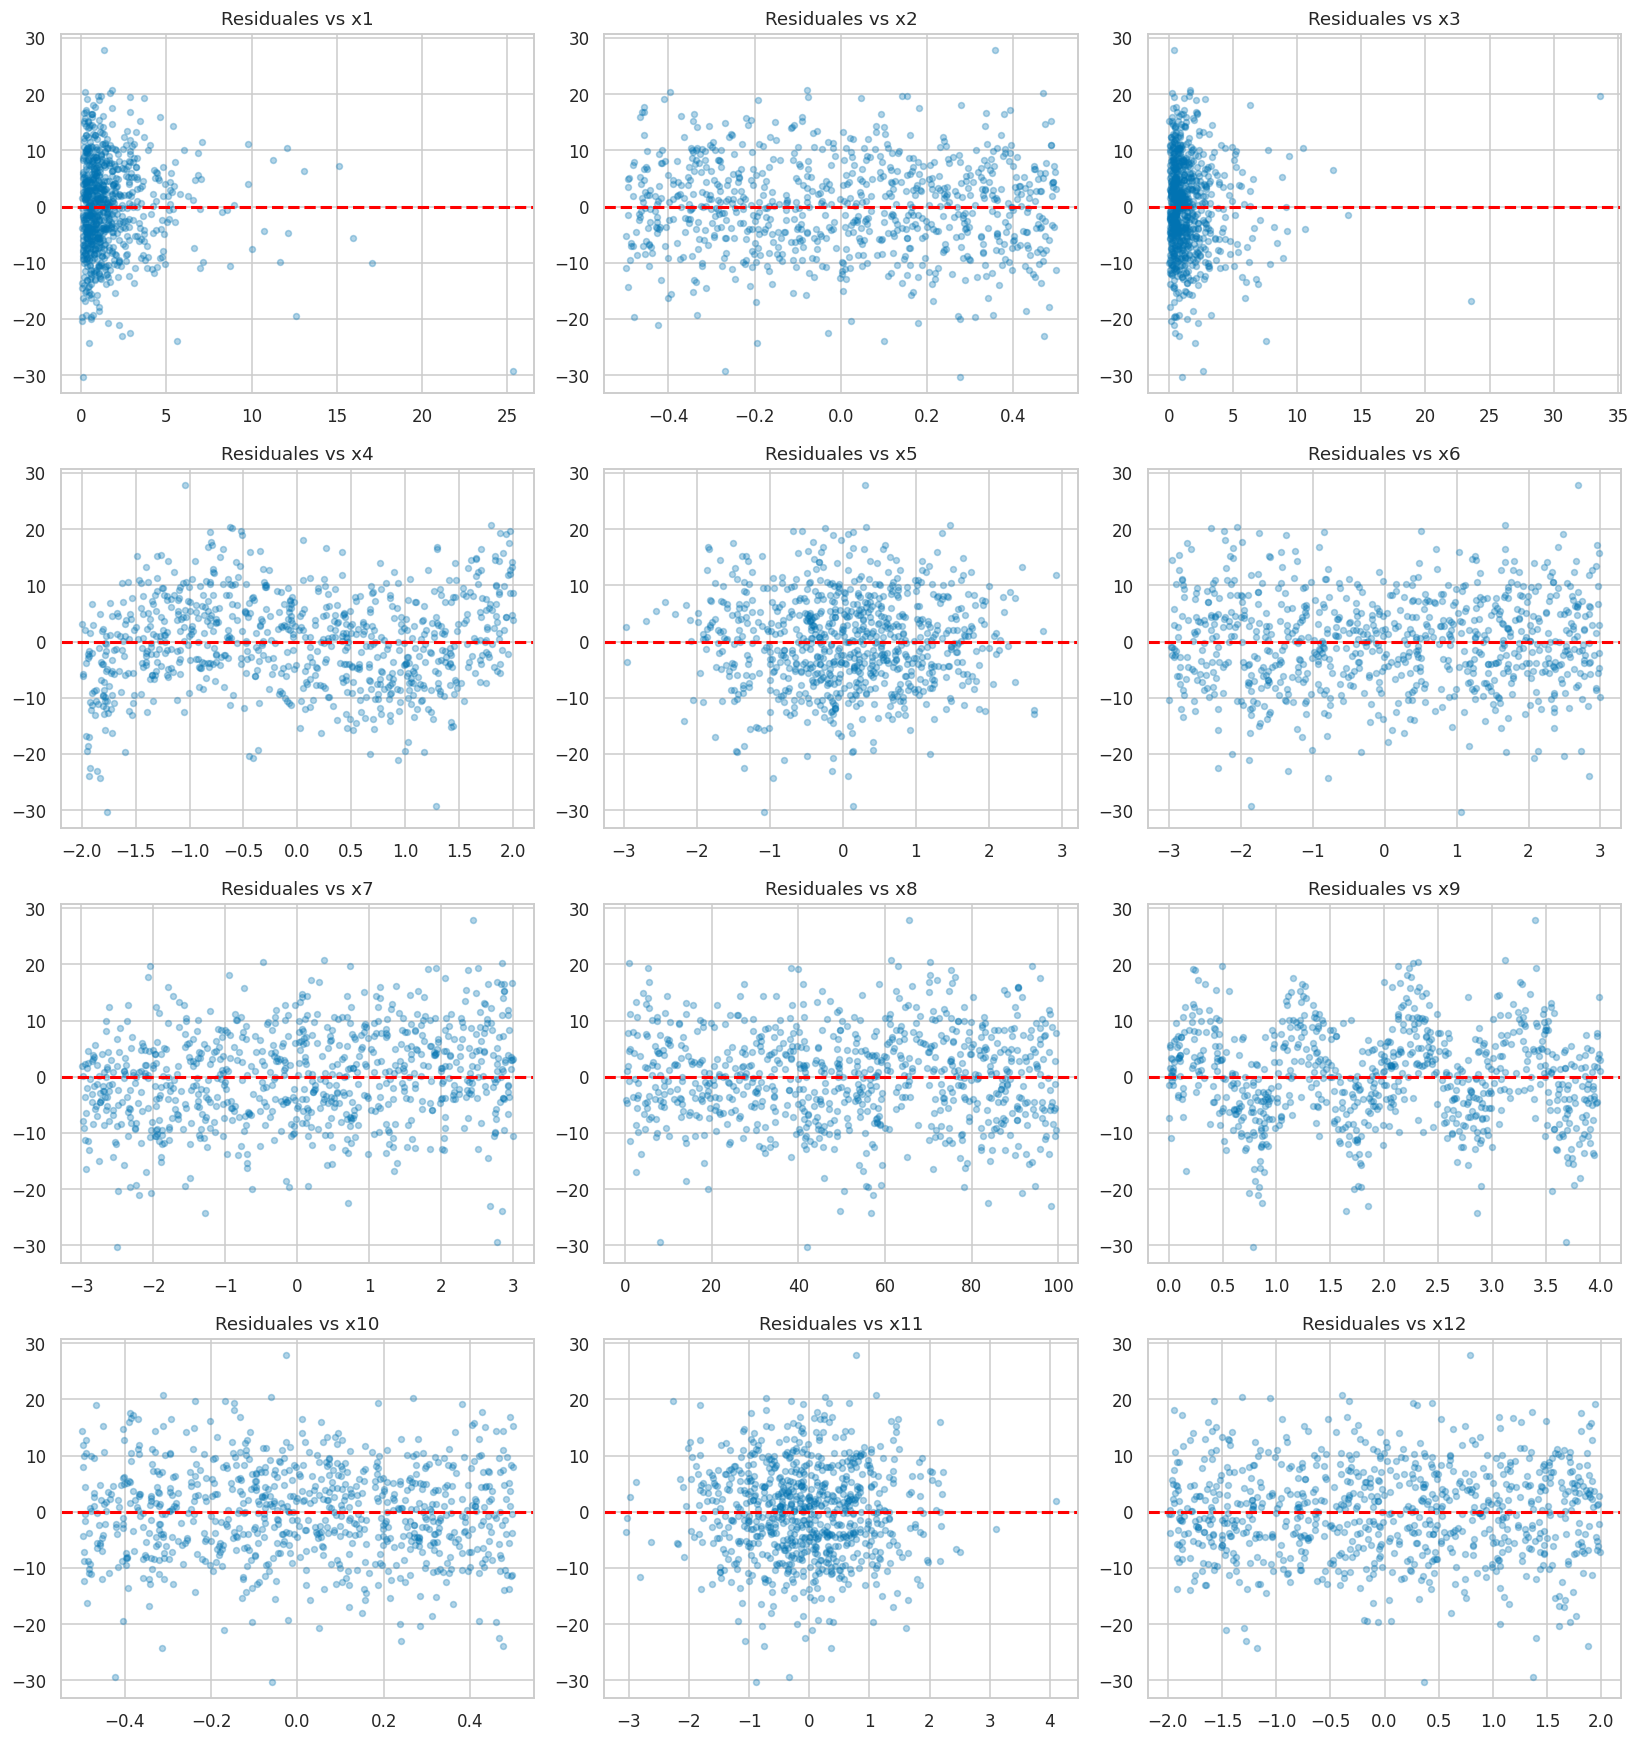

In [88]:

# 1. Separamos solo los 17 términos matemáticos reales (sin las dummies que causaron overfitting)
terminos_reales = {k: v for k, v in modelo_consolidado.items() if not k.startswith(('dummy', 'regimen'))}

# 2. Calculamos predicciones y residuales
X_design = pd.DataFrame(index=train.index)
for k, fn in terminos_reales.items():
    X_design[k] = fn(train)

X_design_mat = np.hstack([np.ones((len(train), 1)), X_design.values])
betas_f, _, _, _ = np.linalg.lstsq(X_design_mat, train["y"].values, rcond=None)
predicciones = X_design_mat @ betas_f
residuales = train["y"].values - predicciones

# 3. Graficamos
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

# Asegúrate de que VARIABLES sea tu lista ['x1', 'x2', ..., 'x12']
for i, var in enumerate(VARIABLES):  
    axes[i].scatter(train[var], residuales, alpha=0.3, s=15)
    axes[i].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'Residuales vs {var}')

plt.tight_layout()
plt.show()

In [89]:
import numpy as np
import pandas as pd

# Volvemos a tu base de 17 términos matemáticos puros (sin dummies)
# Asumiendo que tu diccionario original de 17 términos se llama 'base_purificada'
modelo_final_test = base_purificada.copy()

# Los patrones exactos que vimos en las gráficas residuales
candidatos_visuales = {
    # La onda perfecta de x9 (Periodo de 1)
    "cos_2pi_x9": lambda d: np.cos(2 * np.pi * d["x9"]),
    "sin_2pi_x9": lambda d: np.sin(2 * np.pi * d["x9"]),
    
    # La curva residual de x4
    "x4_cubica": lambda d: d["x4"] ** 3,
    "cos_2x4": lambda d: np.cos(2 * d["x4"]),
    "sin_2x4": lambda d: np.sin(2 * d["x4"])
}

print("=== PROBANDO LOS TÉRMINOS FALTANTES REVELADOS POR LAS GRÁFICAS ===")
mse_actual = 42.74 # Tu piso real sin overfitting

for nombre, fn in candidatos_visuales.items():
    prueba = modelo_final_test.copy()
    prueba[nombre] = fn
    _, mse_test, _, _ = ajusta(prueba) # Usando tu función de ajuste OLS
    
    caida = mse_actual - mse_test
    print(f"Probando {nombre:<15} | Nuevo MSE: {mse_test:.2f} (Caída: {caida:+.2f})")

=== PROBANDO LOS TÉRMINOS FALTANTES REVELADOS POR LAS GRÁFICAS ===
Probando cos_2pi_x9      | Nuevo MSE: 42.48 (Caída: +0.26)
Probando sin_2pi_x9      | Nuevo MSE: 21.93 (Caída: +20.81)
Probando x4_cubica       | Nuevo MSE: 42.68 (Caída: +0.06)
Probando cos_2x4         | Nuevo MSE: 42.61 (Caída: +0.13)
Probando sin_2x4         | Nuevo MSE: 42.64 (Caída: +0.10)


In [91]:
# TODO: agreguen lo que hayan encontrado y midan.

# Consolidamos los hallazgos de la Parte 2 y la Parte 3


modelo_consolidado2 = {
    # --- PARTE 2: Las 17 características base purificadas ---
    "x1_sqrt": lambda d: np.sqrt(np.abs(d["x1"])),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],
    "x4_seno": lambda d: np.sin(d["x4"]),
    "x7_coseno2": lambda d: np.cos(2 * d["x7"]),
    "sin_x3_por_cos_x11": lambda d: np.sin(d["x3"]) * np.cos(d["x11"]),
    "log_x4_por_x5": lambda d: np.log(np.abs(d["x4"]) + 1e-5) * d["x5"],
    "sin_x8_por_x10": lambda d: np.sin(d["x8"]) * d["x10"],
    "inv_x11_por_x12": lambda d: d["x12"] / (np.abs(d["x11"]) + 1e-5),
    "cos_x1_por_cos_x5": lambda d: np.cos(d["x1"]) * np.cos(d["x5"]),
    "sin_x5_por_x11": lambda d: np.sin(d["x5"]) * d["x11"],
    "x8_inversa": lambda d: 1.0 / (np.abs(d["x8"]) + 1e-5),
    "x8_cuadrada": lambda d: d["x8"] ** 2,
    "cos_x8_por_x10_por_x7": lambda d: np.cos(d["x8"]) * d["x10"] * d["x7"],
    "sin_2pi_x9": lambda d: np.sin(2 * np.pi * d["x9"])
}

# Medición del modelo final limpio
_, mse_consolidado2, _, _ = ajusta(modelo_consolidado2)

print("=== MODELO DEFINITIVO PARA ENVÍO ===")
print(f"Total de características: {len(modelo_consolidado2)}")
print(f"MSE de entrenamiento en OLS: {mse_consolidado2:.2f}")

=== MODELO DEFINITIVO PARA ENVÍO ===
Total de características: 18
MSE de entrenamiento en OLS: 21.93


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [42]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Construimos el pipeline con los 3 pasos sugeridos
modelo_fuerza_bruta = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=10000)
)

# Ajustamos el modelo con los datos de entrenamiento
modelo_fuerza_bruta.fit(X_train, y_train)

# Predecimos y evaluamos en validación
predicciones_lasso = modelo_fuerza_bruta.predict(X_val)
mse_lasso = mean_squared_error(y_val, predicciones_lasso)

# Extraemos el modelo LassoCV del pipeline para contar los coeficientes
lasso_entrenado = modelo_fuerza_bruta.named_steps['lassocv']
columnas_totales = len(lasso_entrenado.coef_)
columnas_activas = sum(lasso_entrenado.coef_ != 0)

print(f"Columnas generadas por PolynomialFeatures: {columnas_totales}")
print(f"Columnas distintas de cero (sobrevivientes): {columnas_activas}")
print(f"MSE de validación con LassoCV: {mse_lasso:.2f}")

Columnas generadas por PolynomialFeatures: 454
Columnas distintas de cero (sobrevivientes): 38
MSE de validación con LassoCV: 57.27


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación? El mio fue menor desde que paso de 50 y lo fui puliendo.
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca. Le gano, porque `PolynomialFeatures` solo puede con combinaciones de polinomios enteros. Entre sus opciones no aplica la funcion sinoidal (sin(x9)) o las raizes (sqrt(x1))
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta? De haber ganado la fuerza bruta me hubiera indicado que hay alternativas que no he considerado
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800? Habria fallado, por las pocas observaciones es probable que hubiera un sobreajuste.

*(Su respuesta aquí)*

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | Pense que x1, x3, y x12 necesitaban una transformacion y que el resto debian irse| La primera grafica de la seccion 2 | sqrt a x1, log a x3 (que luego se iria), x12 al cuadrado| 112.51 a 90.89| la eleccion de variables yo, las transformaciones de x1 y x3 la IA |
| 2 | Pense que debia haber mas transformaciones por la primera grafica de la 2|  Porque habia un patron de onda en los puntos de la seccion 1|seno de x9 | empeoro, paso de 90.89 a 92.36| Yo|
| 3 | Pense que si el seno lo empeoro podria probar coseno| fue la misma que la hipotesis 2| cambie el seno por coseno| paso de 92.36 a 89.59| Yo|
| 4 | La grafica de x1 y x3 no cambiaba, asi que discutiendo con la IA me dijo que podia haber combinaciones (sumas o productos)| la segunda grafica del punto 2| probe x1+x3 y x1*x3| La suma no lo cambio y el producto lo empeoro levemente a 90.11| Yo, aunque por esto la IA sugirio probar respecto a otras variables|
| 5 | Probe a partir de mi base el producto de x1 y x3 con las otras variables, tambien el dividirlas| Apartir de este punto deje de buscar por la grafica y busque las relaciones y comportamientos de las variables| x1*x7 y x3*x7 | pasamos 90.06 a 88.47| Fue mi idea|
| 6 | Por la seccion 3 debia haber mas que no considere, y la IA me ayudo a arrojar luz en esto| - | x2 * x7| de 88.47 a 50.56| Fue mi idea, pero la construccion del codigo fue casi pura IA.|
| 7 | Se me ocurrio volver a hacerlo excluyendolos los pares que ya tenia y algo igual que el anterior pero probando para terminos cuadraticos o trigonometricos| - | x6*x9 y sin(x4)| 50.56 a 47.59| Mi idea, codigo de la IA |
| 8 | Estaba creando nuevos bloques termino a termino pero se me ocurrio que debia poder encontrarlos mucho con un while o un for| - | un listado de terminos que estan en la celda 18 | Paso de 47.59 a 30, aunque por temas de que talvez tendria un sobre ajuste lo reduje a 18 terminos (ya eran 42) y paso a un MSE de 42| Mi idea, codigo de la IA|
| 9 | Probe con un modelo de caja negra que llego a un error de 2, asi que debía haber quiebres o cambios de nivel abruptos que no estaba viendo. | Metodo: Extracción e impresión de reglas de un Árbol de Decisión (offline) | 6 umbrales de régimen (ej. indicadora de x8 > 59.53) | 42.74 a 36.55 | La IA sugirió el diagnóstico, ambos lo adaptamos |
| 10 | Las "cotas" (dummies) del árbol causaron sobreajuste al memorizar ruido. El verdadero patrón faltante era matemático y continuo, no de umbrales rígidos. | Gráfica de residuales del modelo base contra cada variable (reveló una onda perfecta en $x_9$) | Se eliminaron las 6 dummies y se agregó la onda exacta: sin(2*pi*x9) | De 36 (56.06 en plataforma) a 21.93  | La plataforma sugirió revisar residuales; la IA y yo identificamos visualmente la onda y el periodo. |


### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

$$\begin{align*} y = \beta_0 &+ \beta_1 \sqrt{\vert{}x_1\vert{}} + \beta_2 \cos(x_9) + \beta_3 x_{12}^2 + \beta_4 (x_1 x_7) + \beta_5 (x_3 x_7) \\ &+ \beta_6 (x_2 x_7) + \beta_7 \sin(x_4) + \beta_8 \cos(2x_7) \\ &+ \beta_9 (\sin(x_3)\cos(x_{11})) + \beta_{10} (\log(\vert{}x_4\vert{}) \cdot x_5) \\ &+ \beta_{11} (\sin(x_8) x_{10}) + \beta_{12} \left(\frac{x_{12}}{\vert{}x_{11}\vert{}}\right) + \beta_{13} (\cos(x_1)\cos(x_5)) \\ &+ \beta_{14} (\sin(x_5) x_{11}) + \beta_{15} \left(\frac{1}{\vert{}x_8\vert{}}\right) + \beta_{16} x_8^2 \\ &+ \beta_{17} (\cos(x_8) x_{10} x_7) \\ &+ \beta_{18} \sin(2\pi x_9) \\ &+ \epsilon \end{align*}$$

(Tal como las genere le pedi que me lo devolviera para markdown)

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

Para empezar, la IA decia que probar coseno era un error, porque solo era el seno recorrido medio pi y que eso hacia que fueran iguales. Esto no me asi sentido ya que por pura logica multiplicar una constante por el seno de algo y por su coseno puede variar bastante. Asi que contra su consejo hice el cambio y resulto que tenia razón. 

Aparte de este tuvo entre otros: 
- Estar enfrazcada en decirme que omitiera a x3 pero que justamente por usarlo se dio cuenta que si era util. 
- En la parte de agregar a x1 y x3 siendo modificadas por x7, me decia que solo debia agregar a x1 y porque x3 seria empeorar las cosas. 
- Nunca considero transformaciones trigonometricas o de potencias o acotando hasta que yo pregunte si es que eran validas. 
- Me sugirio usar cosas que no conozco como random forest y aunque eso parece que me hubiera dado un mejor resultado lo omiti. 

Entre otras

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

En este tercera entrega paso a ser de 21.93, que es mejor que el 23 de /validar. En teoria es mejor lo que me preocupa un poco. Pero a diferencia del anterior ahora ya no hay cotas fijas que puedan hacer un sobreajuste, esta compuesto de puras funciones matematicas. Creo que ya no vale la pena seguir porque si le meto mas cosas es probable que caiga de nuevo en un sobreajuste.


---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [95]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    "x1_sqrt": lambda d: np.sqrt(np.abs(d["x1"])),
    "x9_coseno": lambda d: np.cos(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x7": lambda d: d["x1"] * d["x7"],
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],
    "x4_seno": lambda d: np.sin(d["x4"]),
    "x7_coseno2": lambda d: np.cos(2 * d["x7"]),
    "sin_x3_por_cos_x11": lambda d: np.sin(d["x3"]) * np.cos(d["x11"]),
    "log_x4_por_x5": lambda d: np.log(np.abs(d["x4"]) + 1e-5) * d["x5"],
    "sin_x8_por_x10": lambda d: np.sin(d["x8"]) * d["x10"],
    "inv_x11_por_x12": lambda d: d["x12"] / (np.abs(d["x11"]) + 1e-5),
    "cos_x1_por_cos_x5": lambda d: np.cos(d["x1"]) * np.cos(d["x5"]),
    "sin_x5_por_x11": lambda d: np.sin(d["x5"]) * d["x11"],
    "x8_inversa": lambda d: 1.0 / (np.abs(d["x8"]) + 1e-5),
    "x8_cuadrada": lambda d: d["x8"] ** 2,
    "cos_x8_por_x10_por_x7": lambda d: np.cos(d["x8"]) * d["x10"] * d["x7"],
    "sin_2pi_x9": lambda d: np.sin(2 * np.pi * d["x9"])
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 21.93

Escrito: entregas/tarea-01/v86bd06c0/predicciones.csv
400 predicciones, rango -25.47 a 51.34


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.